In [1]:
!git clone https://github.com/ikrashahid/Jigsaw_Multilingual_Toxic_Comment_Classification.git

fatal: destination path 'Jigsaw_Multilingual_Toxic_Comment_Classification' already exists and is not an empty directory.


In [2]:
%cd Jigsaw_Multilingual_Toxic_Comment_Classification

/content/Jigsaw_Multilingual_Toxic_Comment_Classification


In [3]:
import numpy, pandas, sklearn, torch, transformers
print("numpy", numpy.__version__)
print("pandas", pandas.__version__)
print("sklearn", sklearn.__version__)
print("torch", torch.__version__)
print("transformers", transformers.__version__)

numpy 1.26.4
pandas 2.2.2
sklearn 1.5.1
torch 2.4.1+cu121
transformers 4.44.2


In [4]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
VAL_PATH = "/content/drive/MyDrive/validation.csv"


In [5]:
from assignment_workflow import load_and_split_data
train_df, eval_df = load_and_split_data("/content/drive/MyDrive/jigsaw-unintended-bias-train.csv")
print(train_df.shape, eval_df.shape)

(100000, 13) (20000, 13)


In [6]:
import assignment_workflow, inspect
print(assignment_workflow.__file__)
print(inspect.getsource(assignment_workflow.train_distilbert))

/content/Jigsaw_Multilingual_Toxic_Comment_Classification/assignment_workflow.py
def train_distilbert(
    train_df: pd.DataFrame,
    eval_df: pd.DataFrame,
    output_dir: str = "saved_model/baseline",
):
    set_seed()
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

    train_dataset = tokenize_df(train_df, tokenizer)
    eval_dataset = tokenize_df(eval_df, tokenizer)

    args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        learning_rate=2e-5,
        evaluation_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        report_to=[],
        seed=RANDOM_STATE,
    )

    # NOTE: tokenizer=... is compatible with your current transformers version
    trainer = Trainer(
        model=model,
  

In [7]:
import assignment_workflow, inspect
print(assignment_workflow.__file__)
print("processing_class" in inspect.getsource(assignment_workflow.train_distilbert))

/content/Jigsaw_Multilingual_Toxic_Comment_Classification/assignment_workflow.py
False


Data exists: True


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of DistilBertForSequenceClassification were not initialized from the model chec

Epoch,Training Loss,Validation Loss
1,0.154500,0.145123
2,0.127800,0.169689
3,0.074400,0.230076


Baseline metrics: {'accuracy': 0.948, 'f1_macro': 0.7988447421439104, 'auc_roc': 0.9494608658970086, 'precision': 0.7370653095843935, 'recall': 0.5434646654158849}
Confusion matrix @0.5:
 [[18091   310]
 [  730   869]]

Threshold sweep:
   threshold  f1_macro
0        0.3  0.815982
1        0.4  0.808516
2        0.5  0.798845
3        0.6  0.794823
4        0.7  0.787384


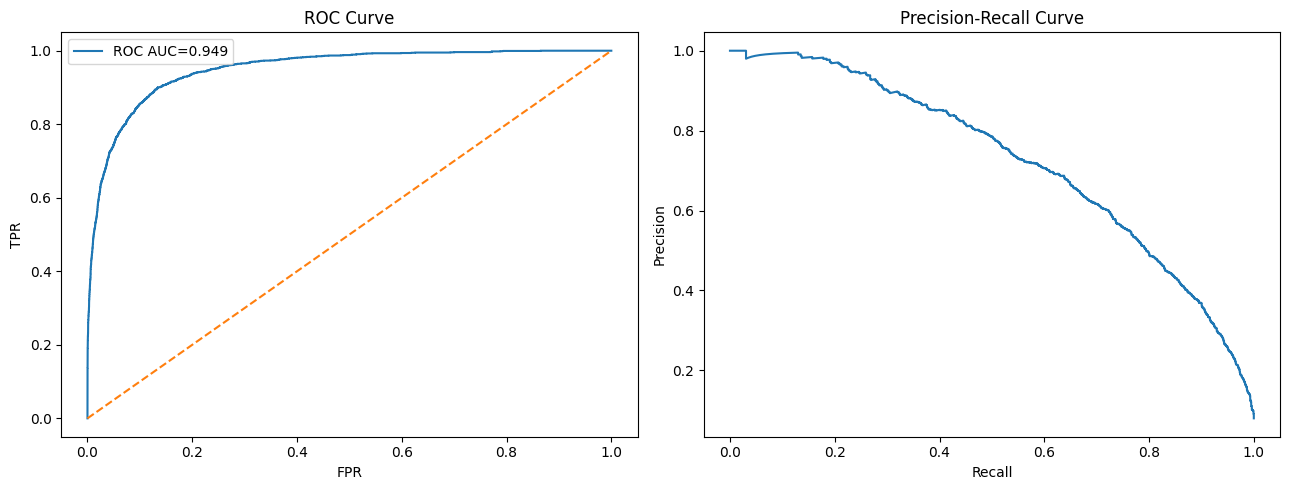

In [8]:
%run part1.ipynb


Data exists: True
Model exists: True


       cohort  size       TPR       FPR       FNR  precision  \
0  high_black   149  0.333333  0.096154  0.666667   0.600000   
1   reference   187  0.365385  0.037037  0.634615   0.791667   

   disparate_impact_ratio_fpr  
0                    2.596154  
1                    2.596154  


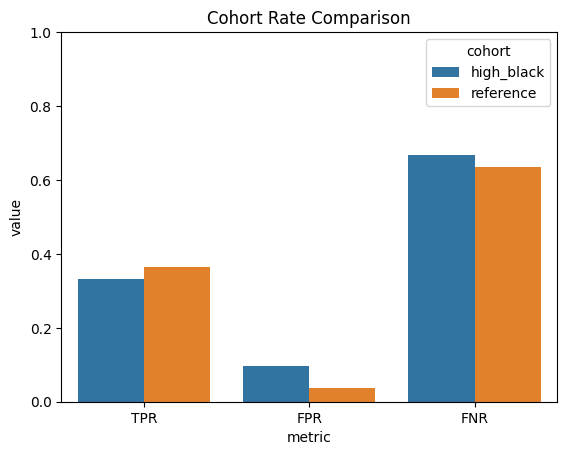

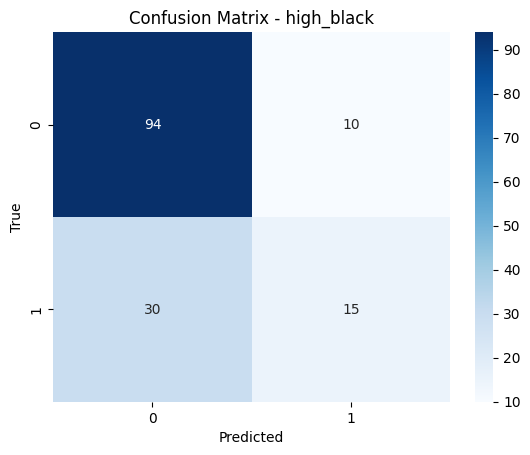

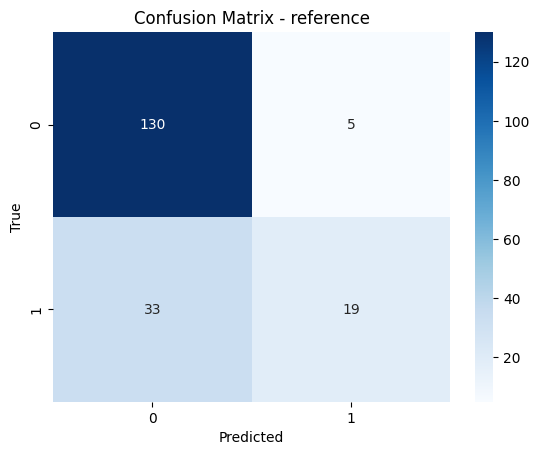

In [9]:
%run part2.ipynb

In [ ]:
%run part3.ipynb

Data exists: True
Model exists: True
Using device: cuda


Eligible toxic/high-confidence comments: 972
{'attack_success_rate': 0.952, 'avg_conf_before': 0.9140282869338989, 'avg_conf_after': 0.05589928850531578}


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss


In [ ]:
%run part4.ipynb

In [ ]:
%run part5.ipynb